# Initialize VI from Laplace

Use {meth}`~liesel.optim.VDist.mvn_tril_from_laplace` to initialize a Gaussian
family from a fitted {class}`~liesel.optim.LaplaceApproximation`. One block covering
all approximation parameters retains the full covariance; separate blocks are
independent.

This example has two latent effects and a shared mean, all on the real line.
Its Gaussian posterior makes the effect of blocking visible. For prerequisites,
see {doc}`optimizer-laplace` and {doc}`variational-inference`.

## Fit the Laplace model

In [1]:
import jax
import jax.numpy as jnp
import optax
import pandas as pd
import tensorflow_probability.substrates.jax.distributions as tfd

import liesel.model as lsl
import liesel.optim as opt

z = lsl.Var.new_param(0.0, dist=lsl.Dist(tfd.Normal, 0.0, 1.0), name="z")

a_loc = lsl.Var.new_calc(
    lambda value: jnp.repeat(value, 2),
    z,
    name="a_loc",
)
a = lsl.Var.new_param(
    jnp.zeros(2),
    dist=lsl.Dist(tfd.MultivariateNormalDiag, a_loc, jnp.ones(2)),
    name="a",
)

total = lsl.Var.new_calc(jnp.sum, a, name="total")
y = lsl.Var.new_obs(
    jnp.array([2.0]),
    dist=lsl.Dist(tfd.Normal, total, 1.0),
    name="y",
)
model = lsl.Model(y)

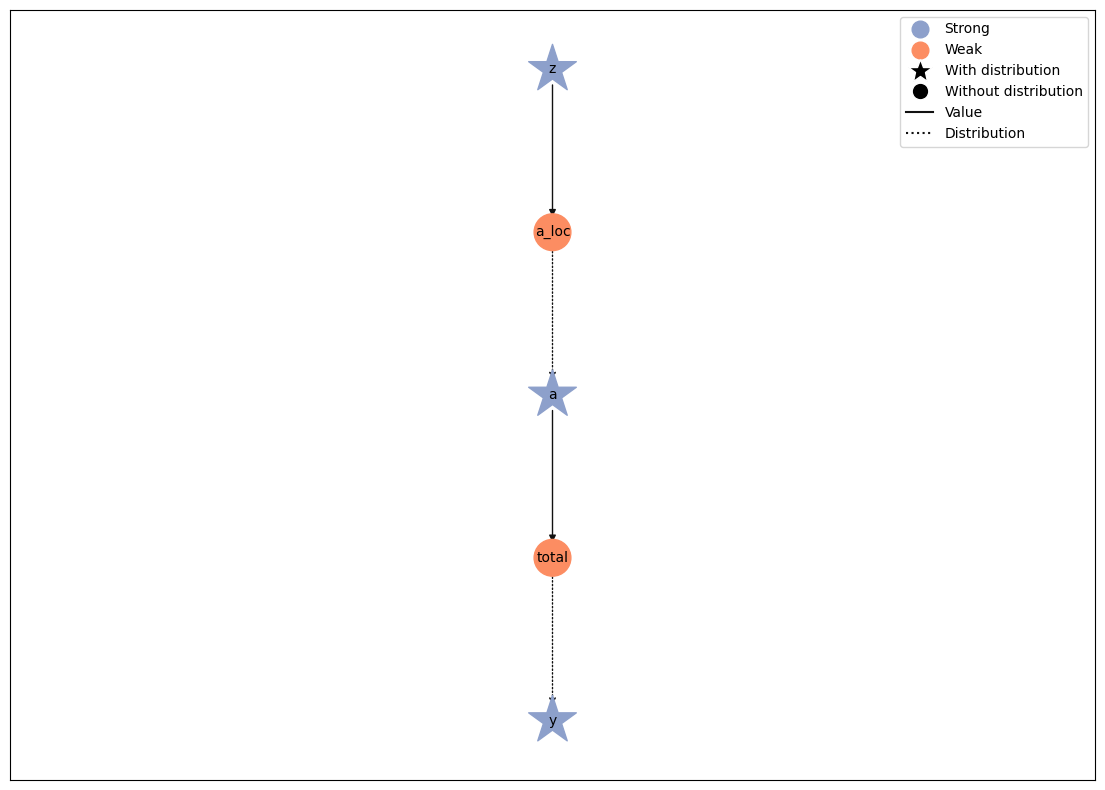

In [2]:
model.plot()

{class}`~liesel.optim.LaplaceLoss` integrates out `a` and optimizes `z`.
The joint approximation includes both. The initializer also accepts output from
{meth}`~liesel.optim.NegLogProbLoss.approximate_joint_posterior`.

In [3]:
split = opt.PositionSplit.from_model(model)
laplace_loss = opt.LaplaceLoss(model, split, latent=["a"])

laplace_result = opt.LieselOptim(
    model,
    loss=laplace_loss,
    optimizers="lbfgs",
    loss_monitor="train_full_data",
    stopper=opt.Stopper(epochs=20, patience=3),
    show_progress=False,
).fit()

approximation = laplace_loss.approximate_joint_posterior(laplace_result)

liesel.optim.engine - INFO - Initializing optimization at epoch 0


In [4]:
pd.Series(
    {name: value.tolist() for name, value in approximation.mean.items()},
    name="Fitted mean",
).to_frame()

,Fitted mean
z,0.571429
a,"[0.8571428656578064, 0.8571428060531616]"


The fitted means are about 0.57 for `z` and 0.86 for each element of `a`.
Initialization requires a valid approximation and adds no jitter.

## Use one dense block

Include every approximation parameter to retain its full covariance. Names and
shapes must match, including transformed names. The helper reorders parameters but
does not transform scales or check that the data and model agree.

In [5]:
dense = (
    opt.VDist(list(approximation.mean), model)
    .mvn_tril_from_laplace(approximation)
    .build()
)

In [6]:
pd.DataFrame(
    dense.var.dist_node.init_dist().covariance(),
    index=["a[0]", "a[1]", "z"],
    columns=["a[0]", "a[1]", "z"],
).round(3)

,a[0],a[1],z
a[0],0.714,-0.286,0.143
a[1],-0.286,0.714,0.143
z,0.143,0.143,0.429


The two effects are negatively correlated; each correlates positively with `z`.
Here the dense family starts at the exact posterior.

## Use independent blocks

Put `a` and `z` into separate blocks to remove cross-block dependence. For each
selected block S, the initializer uses the fitted mean and covariance
`inverse(P_SS)`, where P is the approximation's joint precision. This is the
covariance conditional on **every omitted approximation parameter at its fitted
mean**, not the block's marginal covariance.

In [7]:
a_block = opt.VDist(["a"], model).mvn_tril_from_laplace(approximation)
z_block = opt.VDist(["z"], model).mvn_tril_from_laplace(approximation)
blocked = opt.CompositeVDist(a_block, z_block).build()

In [8]:
pd.DataFrame(
    a_block.var.dist_node.init_dist().covariance(),
    index=["a[0]", "a[1]"],
    columns=["a[0]", "a[1]"],
).round(3)

,a[0],a[1]
a[0],0.667,-0.333
a[1],-0.333,0.667


Each effect's conditional variance is 2/3, versus marginal variance 5/7 in the
dense family. Within-block correlations remain. For a subset, the helper uses
selected precision rows without constructing the full covariance.

For Gaussian targets, these blocks minimize reverse KL under the negative ELBO.
Independence alone does not imply conditional covariance; the objective selects
it. For other targets, this is only an initialization. To start from marginals,
pass their means and covariance Cholesky factors to {meth}`~liesel.optim.VDist.mvn_tril`.

The helper leaves the target unchanged. If omitted parameters stay fixed rather
than entering another block, set them to their fitted means for this conditional
interpretation; the initializer does not adjust selected means for other fixed values.

## Continue with VI

Pass either family to {meth}`~liesel.optim.NegElboLoss.from_vdist`:

In [9]:
vi_loss = opt.NegElboLoss.from_vdist(blocked, nsamples=32)

vi_result = opt.LieselVI(
    model,
    loss=vi_loss,
    optimizers=optax.adam(0.001),
    loss_monitor=opt.EmaTrainLossMonitor(effective_window=20.0),
    stopper=opt.Stopper(epochs=30, patience=30),
    seed=42,
    show_progress=False,
).fit()

posterior = vi_loss.approximate_joint_posterior(vi_result)
draws = posterior.sample(2_000, seed=jax.random.key(43))

liesel.optim.engine - INFO - Initializing optimization at epoch 0


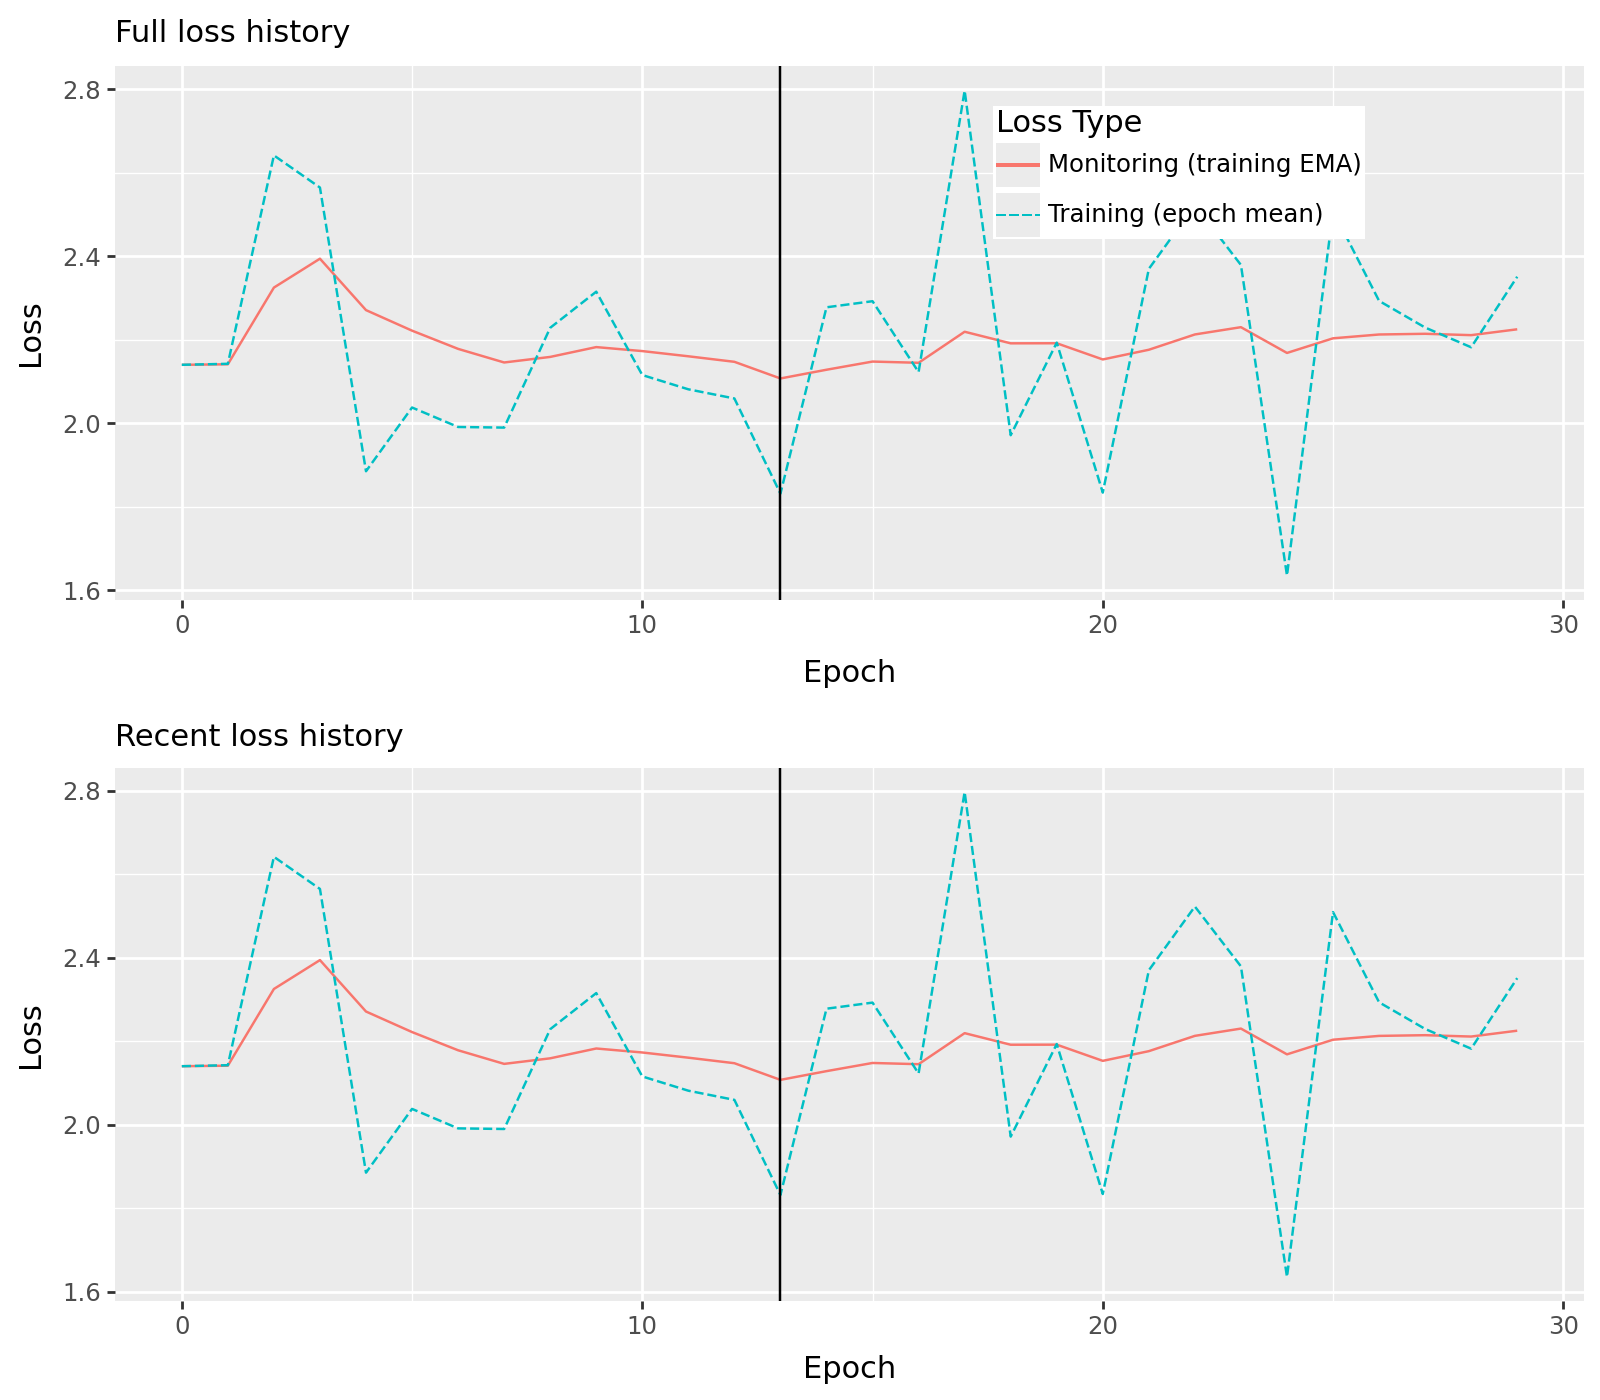

In [10]:
vi_result.plot_loss_overview()

Monte Carlo noise can move the fit away from its starting optimum. Check fitted
uncertainty and predictions as well as the loss curve.

In [11]:
pd.DataFrame(
    {
        "Mean": [draws["z"].mean(), *draws["a"].mean(axis=0)],
        "SD": [draws["z"].std(), *draws["a"].std(axis=0)],
    },
    index=["z", "a[0]", "a[1]"],
).astype(float).round(3)

,Mean,SD
z,0.557,0.595
a[0],0.857,0.810
a[1],0.872,0.821


These draws retain the family's block independence. See {doc}`variational-models`
for other families and {doc}`optimizer-monitoring` for fit diagnostics.